In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
from pathlib import Path

In [2]:
folder = r"C:\Users\zah48132\GSK\Biopharm Model Predictive Control - Documents\General\doc\SAM Lab 1000L Batch November 2025"
file = "CTM_data_for_titer_trajectory.csv"
file_path = Path(folder, file)

df = pd.read_csv(file_path)
df.head()

,Location,Batch,reactor,Batch ID,Day,titer
0,BDSD,DR24-031,658,DR24-031-658,0,NaN
1,BDSD,DR24-031,658,DR24-031-658,1,NaN
2,BDSD,DR24-031,658,DR24-031-658,2,NaN
3,BDSD,DR24-031,658,DR24-031-658,3,NaN
4,BDSD,DR24-031,658,DR24-031-658,4,NaN


In [3]:
df_ctm = df.loc[df["Location"]=="B38", :]
grouped = df_ctm.groupby("Day")["titer"].agg(['mean','std'])
df_agg = grouped.reset_index()
df_agg["high_mean"] = df_agg["mean"] + df_agg["std"]*3
df_agg

,Day,mean,std,high_mean
0,0,21.050000,4.030509,33.141526
1,1,33.150000,2.616295,40.998885
2,2,59.550000,10.253048,90.309145
3,3,120.328571,13.004578,159.342305
4,4,230.314286,22.308999,297.241282
5,5,408.971429,35.335332,514.977426
6,6,708.442857,53.809474,869.871280
7,7,1046.471429,64.357302,1239.543336
8,8,1491.571429,62.262233,1678.358129
9,9,1845.685714,64.588503,2039.451224


In [5]:
smoothed_trajectory = [
    23.9,
    38.5,
    73.5,
    115.6,
    218.4,
    398.4,
    713.8,
    1068.4,
    1537.9,
    1941.5,
    2337.8,
    2603.3,
    2902.5,
    3102.2,
    3225.0,
]

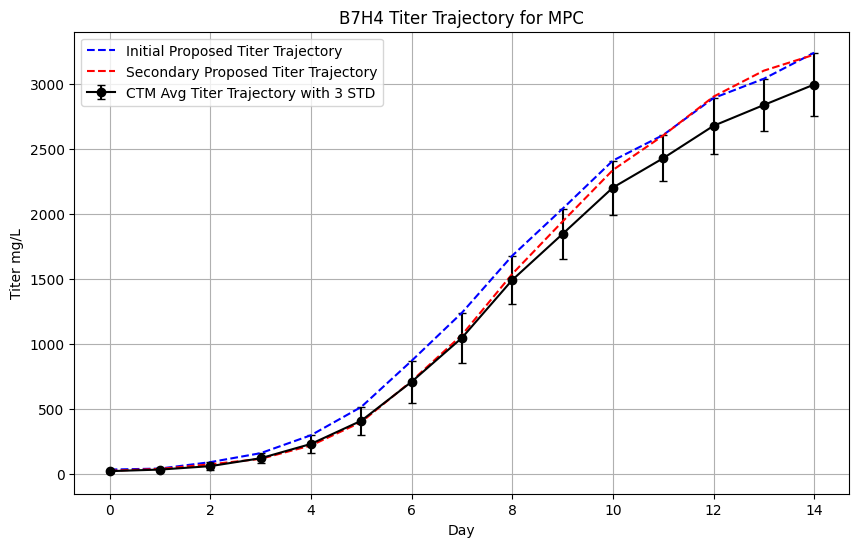

In [10]:
plt.figure(figsize=(10,6))
plt.errorbar(df_agg["Day"], df_agg["mean"], df_agg["std"]*3, fmt="ko-", capsize=3, label="CTM Avg Titer Trajectory with 3 STD")
plt.plot(df_agg["Day"], df_agg["high_mean"], "b--", label="Initial Proposed Titer Trajectory")
plt.plot(df_agg["Day"], smoothed_trajectory, "r--", label="Secondary Proposed Titer Trajectory")
plt.ylabel("Titer mg/L")
plt.xlabel("Day")
plt.title("B7H4 Titer Trajectory for MPC")
plt.grid()
plt.legend()